In [16]:
from huggingface_hub import snapshot_download, hf_hub_download
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import random 

In [ ]:
load_dotenv()
token = os.getenv("HF_TOKEN")
repo = 'valentina2323/GERIS-Goes19-uruguay-fires' #Could be added to .env

In [18]:
date_ini = "2025-11-15 13:00"
date_fin = "2025-11-15 14:00"


time_step = 10 #En minutos
#Tomar fechas cada time_step minutos
dates = pd.date_range(
    start=date_ini,
    end=date_fin,
    freq=f"{time_step}min"
)
print(dates)

DatetimeIndex(['2025-11-15 13:00:00', '2025-11-15 13:10:00',
               '2025-11-15 13:20:00', '2025-11-15 13:30:00',
               '2025-11-15 13:40:00', '2025-11-15 13:50:00',
               '2025-11-15 14:00:00'],
              dtype='datetime64[us]', freq='10min')


In [19]:
for date in dates:

    file_name = date.strftime("%Y%m%d_%H%M") + ".npy"

    for band in ["ABI-L1b-Rad-B07", "ABI-L1b-Rad-B14", "ABI-L2-FDCF-Mask"]:

        file_path = f"uruguay/{band}/{file_name}"

        local_path = hf_hub_download(
            repo_id= repo,
            repo_type="dataset",
            filename=file_path,
            token=token,
            local_dir="dataset"
        )

        print(f"Downloaded: {file_path}")

Downloaded: uruguay/ABI-L1b-Rad-B07/20251115_1300.npy
Downloaded: uruguay/ABI-L1b-Rad-B14/20251115_1300.npy
Downloaded: uruguay/ABI-L2-FDCF-Mask/20251115_1300.npy
Downloaded: uruguay/ABI-L1b-Rad-B07/20251115_1310.npy
Downloaded: uruguay/ABI-L1b-Rad-B14/20251115_1310.npy
Downloaded: uruguay/ABI-L2-FDCF-Mask/20251115_1310.npy
Downloaded: uruguay/ABI-L1b-Rad-B07/20251115_1320.npy
Downloaded: uruguay/ABI-L1b-Rad-B14/20251115_1320.npy
Downloaded: uruguay/ABI-L2-FDCF-Mask/20251115_1320.npy
Downloaded: uruguay/ABI-L1b-Rad-B07/20251115_1330.npy
Downloaded: uruguay/ABI-L1b-Rad-B14/20251115_1330.npy
Downloaded: uruguay/ABI-L2-FDCF-Mask/20251115_1330.npy
Downloaded: uruguay/ABI-L1b-Rad-B07/20251115_1340.npy
Downloaded: uruguay/ABI-L1b-Rad-B14/20251115_1340.npy
Downloaded: uruguay/ABI-L2-FDCF-Mask/20251115_1340.npy
Downloaded: uruguay/ABI-L1b-Rad-B07/20251115_1350.npy
Downloaded: uruguay/ABI-L1b-Rad-B14/20251115_1350.npy
Downloaded: uruguay/ABI-L2-FDCF-Mask/20251115_1350.npy
Downloaded: uruguay/AB

In [9]:
band7_dir = "dataset/uruguay/ABI-L1b-Rad-B07/"
band14_dir = "dataset/uruguay/ABI-L1b-Rad-B14/"
fire_masks_dir = "dataset/uruguay/ABI-L2-FDCF-Mask/"

In [12]:
band7, band14 = [],[]
fire_masks = []


for d in dates:
    file_name = d.strftime("%Y%m%d_%H%M") + ".npy"
    band7.append(np.load(band7_dir+file_name))
    band14.append(np.load(band14_dir+file_name))
    fire_masks.append(np.load(fire_masks_dir+file_name))

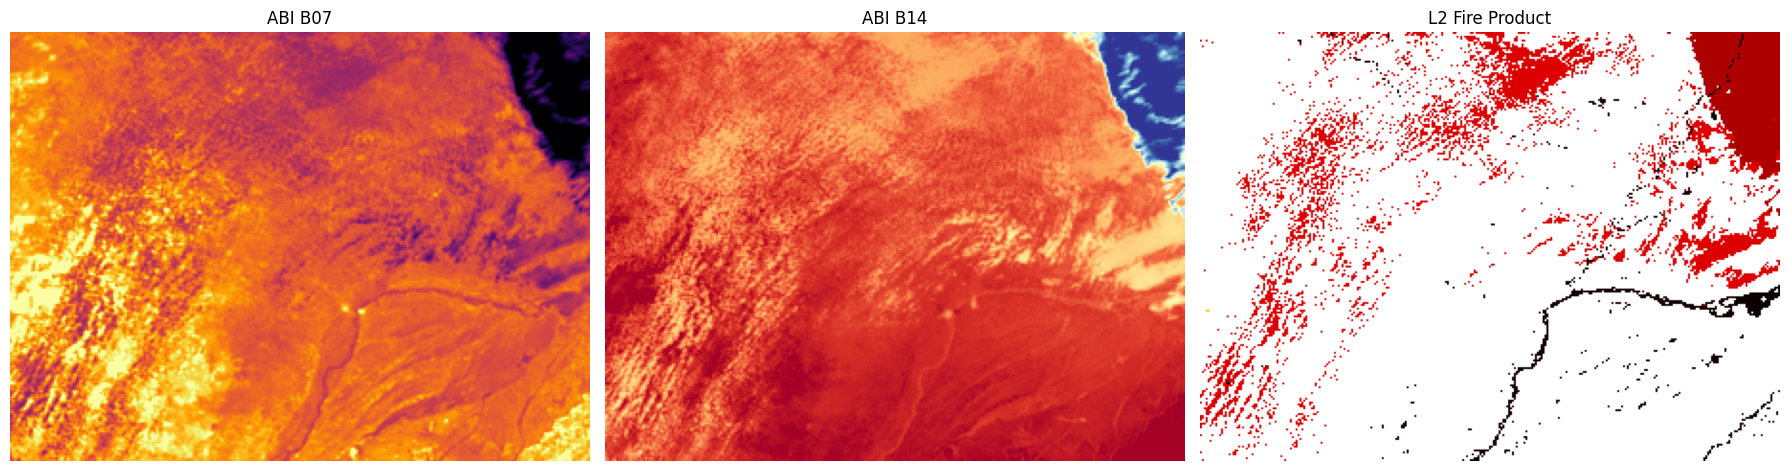

In [ ]:


idx = random.randint(0,len(dates))
b07,b14,fire = band7[idx],band14[idx],fire_masks[idx]

# Create one figure with 3 images side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# B07
vmin, vmax = np.percentile(b07, [2, 98])
axes[0].imshow(b07, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0].set_title("ABI B07")
axes[0].axis("off")

# B14
vmin, vmax = np.percentile(b14, [2, 98])
axes[1].imshow(b14, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
axes[1].set_title("ABI B14")
axes[1].axis("off")

# L2 Fire
axes[2].imshow(fire, cmap="hot")
axes[2].set_title("L2 Fire Product")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Preproccesing

In [ ]:
#Divide images in patches
def get_patches(img: np.ndarray, patch_size = 64, stride = 32):
    ''' 
    Divides img into patches of size patch_size x patch_size.
    '''
    patches = []; coords = []
    H,W = img.shape 
    for y in range(0,H-patch_size+1,stride):
        for x in range(0,W-patch_size+1,stride):
            patch = img[y:y+patch_size,x:x+patch_size]
            patches.append(patch)
            coords.append((y,x))
    return patches, coords

| Time \ Patch | 0 | 1 | 2 | 3 | ... | N-1 |
|---|---|---|---|---|---|---|
| Date 0 | P₀,₀ | P₀,₁ | P₀,₂ | P₀,₃ | ... | P₀,ₙ₋₁ |
| Date 1 | P₁,₀ | P₁,₁ | P₁,₂ | P₁,₃ | ... | P₁,ₙ₋₁ |
| Date 2 | P₂,₀ | P₂,₁ | P₂,₂ | P₂,₃ | ... | P₂,ₙ₋₁ |
| ... | ... | ... | ... | ... | ... | ... |
| Date T-1 | Pₜ₋₁,₀ | Pₜ₋₁,₁ | Pₜ₋₁,₂ | Pₜ₋₁,₃ | ... | Pₜ₋₁,ₙ₋₁ |


Each P is a patch of a certain image at a certain time.

In [ ]:
n_img = len(band7)
patches7,patches14,patches_fire = [],[],[]
for i in range(n_img):
    p7,_ = get_patches(band7[i])
    p14,_ = get_patches(band14[i])
    pf,_ = get_patches(fire_masks[i])


    patches7.append(p7)
    patches14.append(p14)
    patches_fire.append(pf)


#Each column in the (TxN) array is a time series. Each line contains the patches for a specific time.
patches7 = np.stack(patches7, axis=0)
patches14 = np.stack(patches14, axis=0)
patches_fire = np.stack(patches_fire, axis=0)

# Training

In [ ]:
seq_len = 5 #Amount of previous images used to predict fire at a given time
T, N, H, W = patches7.shape
train_end = int(T*0.8)

In [ ]:
patches_fire = np.isin(patches_fire,[13,14,15]).any()
X_train = []
y_train = []

X_val = []
y_val = []

for patch in range(N):

    for t in range(T - seq_len):

        seq7 = patches7[t:t+seq_len, patch]
        seq14 = patches14[t:t+seq_len, patch]

        sequence = np.stack(
            [seq7, seq14],
            axis=-1
        )

        target = patches_fire[t + seq_len, patch]

        if t + seq_len < train_end:
            X_train.append(sequence)
            y_train.append(target)
        else:
            X_val.append(sequence)
            y_val.append(target)

X_train = np.array(X_train)
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

In [ ]:
from convlstm import ConvLSTM
import torch.nn as nn

In [ ]:

X_train = np.transpose(X_train, (0, 1, 4, 2, 3)) #Convlstm expects channels before the spatial dims
X_val = np.transpose(X_val, (0, 1, 4, 2, 3))

#Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FireConvLSTM().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
from cnn_lstm import train_model

results = train_model(train_loader,val_loader,20,model,criterion,optimizer,device)

In [ ]:
from cnn_lstm import compute_metrics

metrics = compute_metrics(model,val_loader,device)